# LSTM Baseline for Helpful Vote Prediction

This notebook builds a simple LSTM baseline model for predicting whether an Amazon review is helpful (`helpful_vote > 0`).

In [1]:
# Install dependencies for this notebook (safe to run multiple times).
import sys
import subprocess

base_packages = [
    "pip",
    "setuptools",
    "wheel",
    "numpy",
    "pandas",
    "matplotlib",
    "scikit-learn",
]

deep_learning_packages = [
    "torch",
]

print("Upgrading packaging tools and installing core dependencies...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *base_packages])
print("Installing PyTorch...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *deep_learning_packages])
print("Dependency installation complete.")
print("If imports still fail, restart the notebook kernel once and re-run from the top.")

Upgrading packaging tools and installing core dependencies...
Installing PyTorch...
Dependency installation complete.
If imports still fail, restart the notebook kernel once and re-run from the top.


In [2]:
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [10]:
# -----------------------------
# 1) Load data
# -----------------------------
# Robust dataset discovery for different notebook working directories.
cwd = Path.cwd()
workspace_root = cwd if (cwd / "data").exists() else (cwd.parent if (cwd.parent / "data").exists() else cwd)

candidate_paths = [
    cwd / "s_10.csv",
    cwd / "amazon_reviews_s10.csv",
    cwd / "data" / "processed" / "s_10.csv",
    cwd / "data" / "processed" / "amazon_reviews_s10.csv",
    workspace_root / "data" / "processed" / "s_10.csv",
    workspace_root / "data" / "processed" / "amazon_reviews_s10.csv",
]

# Fallback recursive search for both expected filenames.
for filename in ["s_10.csv", "amazon_reviews_s10.csv"]:
    candidate_paths.extend(list(workspace_root.rglob(filename)))

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        f"Could not find s_10.csv or amazon_reviews_s10.csv from working directory: {cwd}"
    )

print("Using dataset:", data_path.resolve())
df = pd.read_csv(data_path)

required_cols = [
    "rating", "images", "parent_asin", "timestamp", "helpful_vote", "review_text",
    "review_length", "is_verified", "image_count", "has_image",
    "days_since_first_review", "product_popularity"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()
df.head()

Using dataset: C:\Lithika\WM9B7-AIDL-AmazonReview\data\processed\amazon_reviews_s10.csv


,rating,images,parent_asin,timestamp,helpful_vote,review_text,review_length,is_verified,image_count,has_image,days_since_first_review,product_popularity
0,5,[],B0051VVOB2,2012-01-28 13:35:06.000,3,Kindle Fire Initially I had trouble using the ...,1832,1,0,False,5548,13072
1,5,[],B010BWYDYA,2008-11-26 16:11:05.000,2,I'm amazed This is my first experience with an...,445,1,0,False,4390,16910
2,5,[],B0051VVOB2,2011-12-25 19:15:13.000,4,Fabulous!! I absolutely Love the Kindle Fire. ...,701,1,0,False,5515,13072
3,5,[],B0791TX5P5,2019-09-18 17:01:20.700,2,Great but not without flaws and quirks. I don’...,1193,1,0,False,8339,10077
4,1,[],B075X8471B,2017-01-25 22:45:43.000,3,Dose not work with Echo Dot....... This item w...,283,1,0,False,7373,9195


In [11]:
# -----------------------------
# 2) Basic preprocessing
# -----------------------------
# Binary target: helpful = 1 if helpful_vote > 0 else 0
df["helpful"] = (df["helpful_vote"].fillna(0) > 0).astype(int)

# Handle missing text values and normalize case
df["review_text"] = df["review_text"].fillna("").astype(str).str.lower().str.strip()

# Ensure review_length exists and is numeric
if df["review_length"].isna().all():
    df["review_length"] = df["review_text"].str.len()
else:
    df["review_length"] = pd.to_numeric(df["review_length"], errors="coerce")
    df["review_length"] = df["review_length"].fillna(df["review_text"].str.len())

# Normalize verification flag for plotting
df["is_verified"] = df["is_verified"].fillna(0)

# Remove rows with empty review text after cleaning
df = df[df["review_text"].str.len() > 0].copy()

print("Shape after preprocessing:", df.shape)
print(df[["helpful_vote", "helpful", "review_text", "review_length", "is_verified"]].head())

Shape after preprocessing: (942176, 13)
   helpful_vote  helpful                                        review_text  \
0             3        1  kindle fire initially i had trouble using the ...   
1             2        1  i'm amazed this is my first experience with an...   
2             4        1  fabulous!! i absolutely love the kindle fire. ...   
3             2        1  great but not without flaws and quirks. i don’...   
4             3        1  dose not work with echo dot....... this item w...   

   review_length  is_verified  
0           1832            1  
1            445            1  
2            701            1  
3           1193            1  
4            283            1  


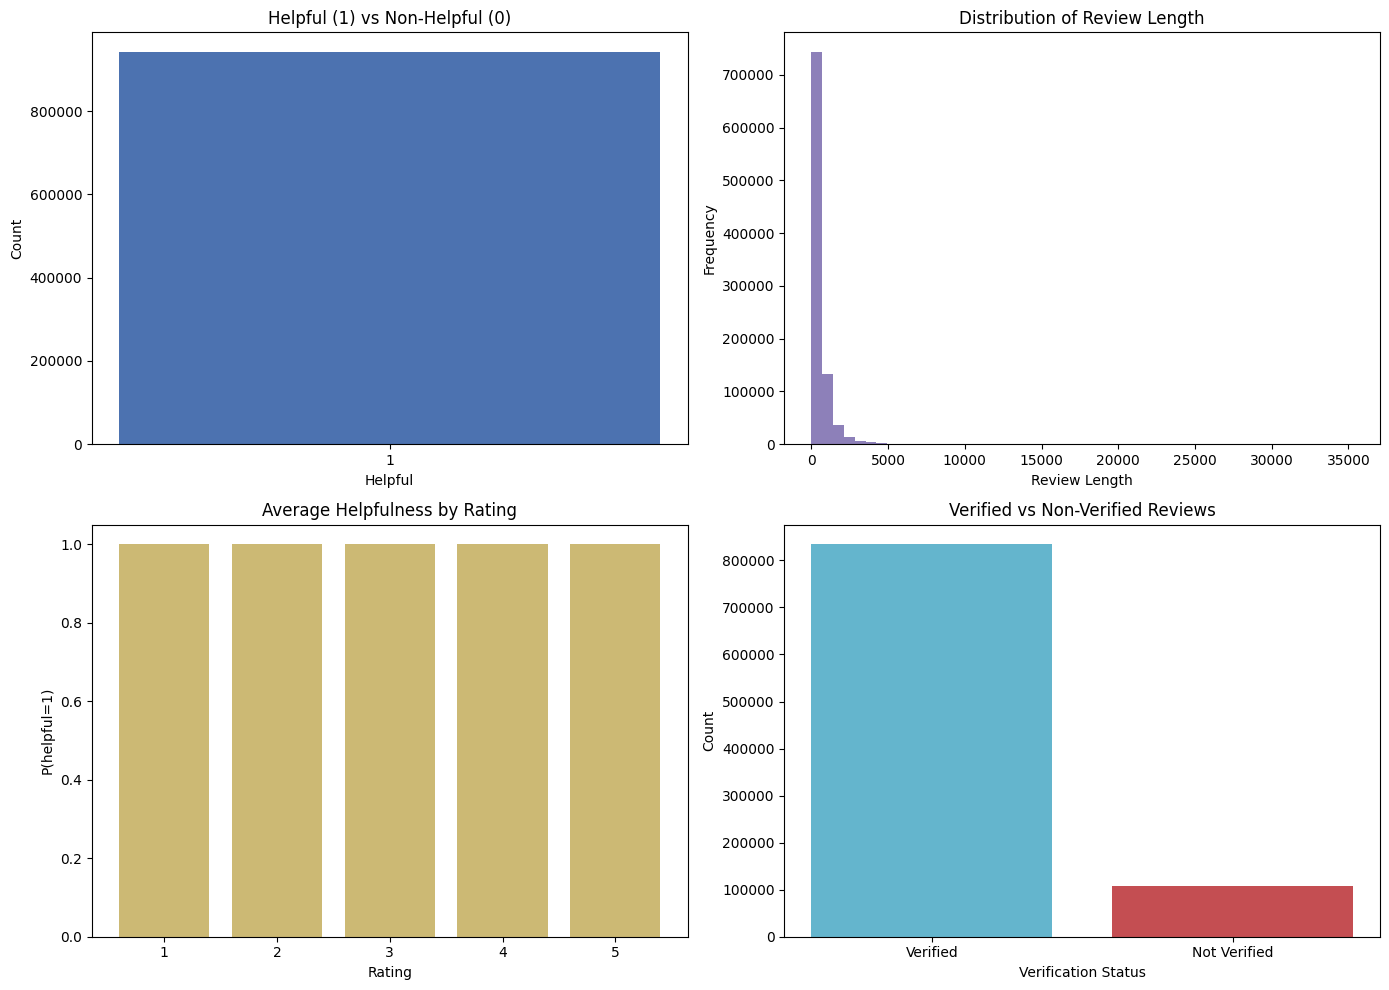

In [12]:
# -----------------------------
# 3) EDA and visualizations
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Helpful vs non-helpful
helpful_counts = df["helpful"].value_counts().sort_index()
axes[0, 0].bar(helpful_counts.index.astype(str), helpful_counts.values, color=["#4C72B0", "#55A868"])
axes[0, 0].set_title("Helpful (1) vs Non-Helpful (0)")
axes[0, 0].set_xlabel("Helpful")
axes[0, 0].set_ylabel("Count")

# (b) Review length distribution
axes[0, 1].hist(df["review_length"].values, bins=50, color="#8172B2", alpha=0.9)
axes[0, 1].set_title("Distribution of Review Length")
axes[0, 1].set_xlabel("Review Length")
axes[0, 1].set_ylabel("Frequency")

# (c) Rating vs helpfulness
rating_helpful = df.groupby("rating", as_index=False)["helpful"].mean()
axes[1, 0].bar(rating_helpful["rating"].astype(str), rating_helpful["helpful"], color="#CCB974")
axes[1, 0].set_title("Average Helpfulness by Rating")
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("P(helpful=1)")

# (d) Verified vs non-verified reviews
verified_counts = df["is_verified"].astype(int).map({1: "Verified", 0: "Not Verified"}).value_counts()
axes[1, 1].bar(verified_counts.index, verified_counts.values, color=["#64B5CD", "#C44E52"])
axes[1, 1].set_title("Verified vs Non-Verified Reviews")
axes[1, 1].set_xlabel("Verification Status")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

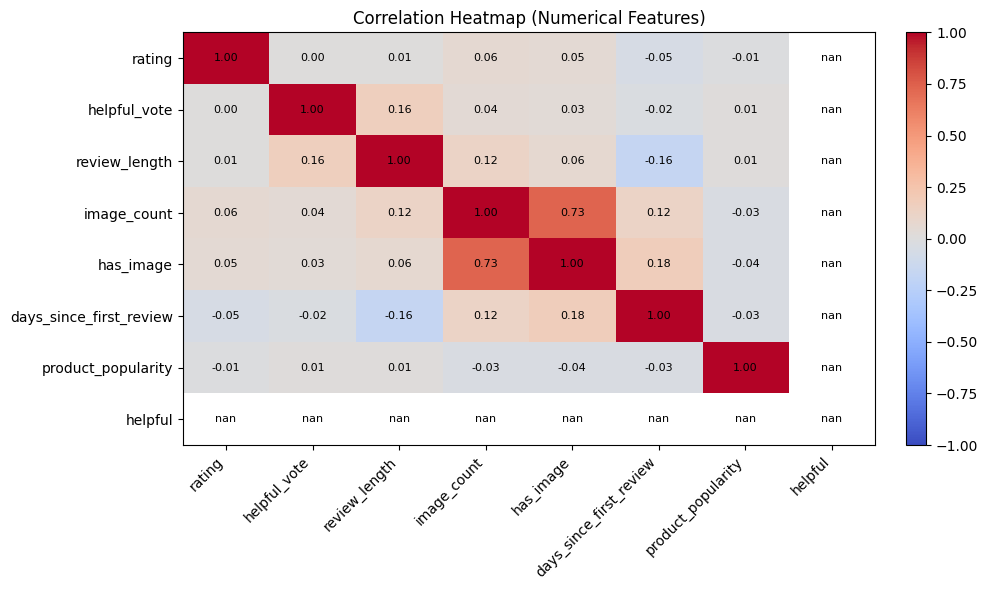

In [13]:
# Optional: Correlation heatmap for numerical features
num_cols = [
    "rating", "helpful_vote", "review_length", "image_count",
    "has_image", "days_since_first_review", "product_popularity", "helpful"
]
available_num_cols = [c for c in num_cols if c in df.columns]

corr = df[available_num_cols].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(10, 6))
im = plt.imshow(corr.values, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(corr.index)), labels=corr.index)
plt.title("Correlation Heatmap (Numerical Features)")

# Annotate values for readability
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
# -----------------------------
# 4) Text tokenization + padding
# -----------------------------
# Convert to plain NumPy arrays to avoid Arrow-backed indexing issues.
X_text = df["review_text"].astype(str).to_numpy(dtype=object)
y = df["helpful"].astype(np.int64).to_numpy()

# Train/test split (stratified to preserve class balance)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

MAX_VOCAB = 50000
MAX_LEN = 200
PAD_ID = 0
OOV_ID = 1


def simple_tokenize(text):
    # Keep only alphanumeric word tokens.
    return re.findall(r"\b\w+\b", text.lower())


# Build vocabulary from train set only.
counter = Counter()
for text in X_train_text:
    counter.update(simple_tokenize(text))

most_common_tokens = counter.most_common(MAX_VOCAB - 2)
word2idx = {word: idx + 2 for idx, (word, _) in enumerate(most_common_tokens)}


def text_to_ids(text, mapping, max_len, pad_id=0, oov_id=1):
    ids = [mapping.get(tok, oov_id) for tok in simple_tokenize(text)]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [pad_id] * (max_len - len(ids))
    return ids


X_train_pad = np.array([text_to_ids(t, word2idx, MAX_LEN, PAD_ID, OOV_ID) for t in X_train_text], dtype=np.int64)
X_test_pad = np.array([text_to_ids(t, word2idx, MAX_LEN, PAD_ID, OOV_ID) for t in X_test_text], dtype=np.int64)

vocab_size = len(word2idx) + 2

print("Train shape:", X_train_pad.shape)
print("Test shape:", X_test_pad.shape)
print("Vocab size:", vocab_size)

Train shape: (753740, 200)
Test shape: (188436, 200)
Vocab size: 50000


In [16]:
# -----------------------------
# 5) Build LSTM baseline model (PyTorch)
# -----------------------------
EMBED_DIM = 64
LSTM_UNITS = 64
DROPOUT = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, lstm_units, pad_idx=0, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, lstm_units, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_units, 1)

    def forward(self, x):
        emb = self.embedding(x)
        _, (hidden, _) = self.lstm(emb)
        last_hidden = hidden[-1]
        out = self.dropout(last_hidden)
        logits = self.fc(out).squeeze(1)
        return logits


model = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS,
    pad_idx=PAD_ID,
    dropout=DROPOUT,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

Using device: cpu
LSTMClassifier(
  (embedding): Embedding(50000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [17]:
# -----------------------------
# 6) Train model
# -----------------------------
EPOCHS = 4
BATCH_SIZE = 256

# Build train/validation split from training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.2, random_state=42, stratify=y_train
)

train_ds = TensorDataset(
    torch.tensor(X_tr, dtype=torch.long),
    torch.tensor(y_tr, dtype=torch.float32),
)
val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.long),
    torch.tensor(y_val, dtype=torch.float32),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    train_loss_total = 0.0
    train_correct = 0
    train_count = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * xb.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        train_correct += (preds == yb).sum().item()
        train_count += xb.size(0)

    train_loss = train_loss_total / train_count
    train_acc = train_correct / train_count

    # ---- Validation ----
    model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_count = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss_total += loss.item() * xb.size(0)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            val_correct += (preds == yb).sum().item()
            val_count += xb.size(0)

    val_loss = val_loss_total / val_count
    val_acc = val_correct / val_count

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} - "
        f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
        f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}"
    )

Epoch 1/4 - loss: 0.0066 - acc: 1.0000 - val_loss: 0.0000 - val_acc: 1.0000


KeyboardInterrupt: 

In [ ]:
# -----------------------------
# 7) Evaluate model
# -----------------------------
test_ds = TensorDataset(
    torch.tensor(X_test_pad, dtype=torch.long),
    torch.tensor(y_test, dtype=torch.float32),
)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs.tolist())
        all_true.extend(yb.numpy().tolist())

y_prob = np.array(all_probs)
y_true = np.array(all_true).astype(int)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], [0, 1])
plt.yticks([0, 1], [0, 1])
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------
# 8) Training curves
# -----------------------------
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist.index + 1, hist["loss"], marker="o", label="train_loss")
axes[0].plot(hist.index + 1, hist["val_loss"], marker="o", label="val_loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(hist.index + 1, hist["accuracy"], marker="o", label="train_acc")
axes[1].plot(hist.index + 1, hist["val_accuracy"], marker="o", label="val_acc")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Future improvement idea: Add metadata features

A next baseline can combine text and metadata in a multi-input network:
- Text branch: Embedding -> LSTM
- Metadata branch: standardized numeric/categorical features such as `rating`, `review_length`, and `is_verified`
- Concatenate both branches before the final dense layers

This often improves performance over text-only models when metadata carries predictive signal.